who else spent big on political-ish FB ads around the may 2022 election, and how do their patterns compare. input is v3 from notebook 04, advocacy rows only.

setup

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, sum as spark_sum, count as spark_count, countDistinct,
    when, lit, date_trunc, desc, broadcast,
)
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

spark = SparkSession.builder \
    .appName('FB_API_election_spenders') \
    .config('spark.sql.parquet.output.committer.class',
            'org.apache.parquet.hadoop.ParquetOutputCommitter') \
    .config('mapreduce.fileoutputcommitter.algorithm.version', '2') \
    .getOrCreate()

print('Master:', spark.sparkContext.master)
print('Spark version:', spark.version)

Master: yarn
Spark version: 3.5.0


26/05/18 05:24:35 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [2]:
V3_PATH = '/user/s3348393/main/preprocessing/v3/parquet'

ELECTION_DATE = pd.Timestamp('2022-05-21')
WINDOW_START  = pd.Timestamp('2021-11-21')
WINDOW_END    = pd.Timestamp('2022-11-21')

# Consistent palette across every chart in this notebook so the same advertiser
# type reads the same colour everywhere.
GROUP_COLORS = {
    'candidate':           '#1f77b4',   # blue
    'party_org':           '#ff7f0e',   # orange
    'climate':             '#2ca02c',   # green
    'humanitarian_rights': '#d62728',   # red
    'political_advocacy':  '#9467bd',   # purple
    'cost_of_living':      '#8c564b',   # brown
    'mixed':               '#bcbd22',   # olive
}

load v3, drop candidates and parties, tag group and pre/post period, cache.

In [3]:
v3 = spark.read.parquet(V3_PATH)

# Drop candidate and party_org — focus on advocacy ecosystem only.
v3 = v3.filter(col('match_type').isNull())

# Use category as the group label (climate / humanitarian_rights / political_advocacy / cost_of_living / mixed).
v3 = v3.withColumn('group', col('category'))

# Tag pre/post election by ad creation date.
v3 = v3.withColumn(
    'period',
    when(col('ad_creation_date') < lit('2022-05-21'), 'pre')
    .otherwise('post')
)

v3 = v3.cache()
print(f'Advocacy ads in v3: {v3.count():,}')
print('\nGroup distribution:')
v3.groupBy('group').agg(
    spark_count('*').alias('ads'),
    spark_sum('spend_mid').alias('total_spend'),
).orderBy(desc('total_spend')).show(truncate=False)

26/05/18 05:24:45 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Advocacy ads in v3: 94,358

Group distribution:
+-------------------+-----+-----------+
|group              |ads  |total_spend|
+-------------------+-----+-----------+
|political_advocacy |34108|7886996.0  |
|climate            |28981|7201909.5  |
|mixed              |15834|3498133.0  |
|humanitarian_rights|9076 |3236462.0  |
|cost_of_living     |6359 |2267220.5  |
+-------------------+-----+-----------+



top 20 bylines by pre-election spend, with post spend and modal group. banding happens later in cell 11.

In [4]:
# per-byline pre and post spend totals.
byline_spend = (v3
    .filter(col('spend_mid').isNotNull() & col('bylines').isNotNull())
    .groupBy('bylines')
    .pivot('period', ['pre', 'post'])
    .agg(spark_sum('spend_mid'))
).na.fill(0)

# modal group per byline.
group_per_byline = (v3.filter(col('bylines').isNotNull())
    .groupBy('bylines', 'group').count()
    .toPandas())

primary_group = (group_per_byline
    .sort_values(['bylines', 'count'], ascending=[True, False])
    .drop_duplicates('bylines', keep='first')
    [['bylines', 'group']])

spend_pdf = byline_spend.toPandas()
spend_pdf.columns = ['bylines', 'pre_spend', 'post_spend']
spend_pdf = spend_pdf.merge(primary_group, on='bylines', how='left')
spend_pdf['total_spend'] = spend_pdf['pre_spend'] + spend_pdf['post_spend']

top20 = spend_pdf.sort_values('pre_spend', ascending=False).head(20).reset_index(drop=True)
top20[['bylines', 'group', 'pre_spend', 'post_spend', 'total_spend']]

,bylines,group,pre_spend,post_spend,total_spend
0,Greenpeace Australia Pacific,climate,809723.0,747046.5,1556769.5
1,Amnesty International Australia,humanitarian_rights,706331.5,148487.5,854819.0
2,Solutions for Australia,climate,588735.5,67405.0,656140.5
3,Climate 200,political_advocacy,514056.5,115618.0,629674.5
4,Australian Conservation Foundation,climate,387769.0,257216.5,644985.5
5,Thrive By Five,humanitarian_rights,379709.0,233141.0,612850.0
6,The Pharmacy Guild of Australia,cost_of_living,335291.5,0.0,335291.5
7,Australia for UNHCR,humanitarian_rights,332935.5,181999.0,514934.5
8,Smart Voting,political_advocacy,302671.5,0.0,302671.5
9,Australian Unions,political_advocacy,262517.0,280910.5,543427.5


cumulative spend per byline. election-only ones elbow at election day, ongoing ones climb steady.

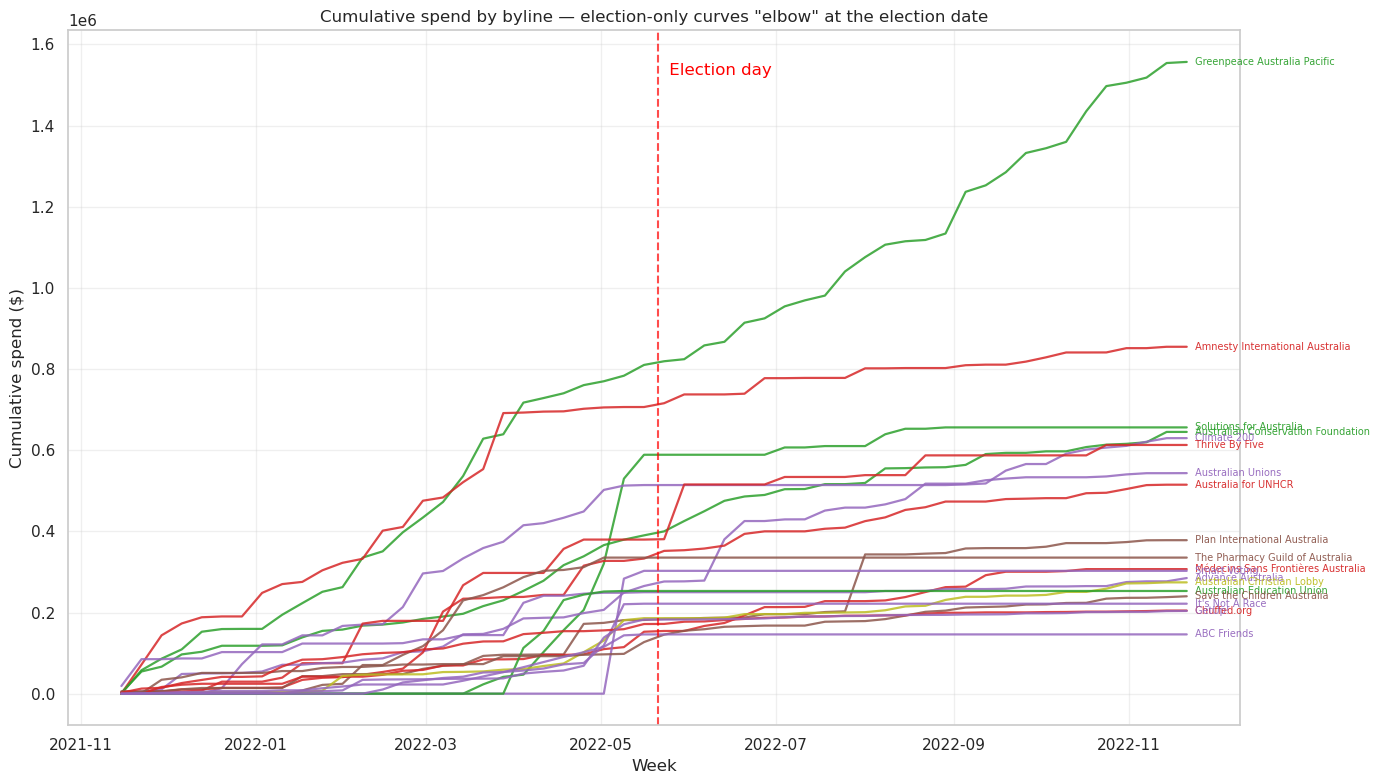

In [5]:
top20_bylines = top20['bylines'].tolist()

# Weekly aggregation per byline — cached on driver as pandas, reused by every chart below.
weekly = (v3
    .filter(col('bylines').isin(top20_bylines) & col('spend_mid').isNotNull())
    .withColumn('week', date_trunc('week', 'ad_creation_date'))
    .groupBy('week', 'bylines', 'group')
    .agg(spark_sum('spend_mid').alias('spend'))
    .orderBy('week')
    .toPandas())

# Pivot to byline × week (used by stacked/cumulative/heatmap charts below).
pivot = weekly.pivot_table(index='week', columns='bylines', values='spend', aggfunc='sum').fillna(0)
col_order = pivot.sum().sort_values(ascending=False).index.tolist()
pivot = pivot[col_order]
byline_group = dict(zip(top20['bylines'], top20['group']))

# Cumulative spend per byline — the elbow tells the story.
cumulative = pivot.cumsum()

fig, ax = plt.subplots(figsize=(14, 8))
for byline in cumulative.columns:
    grp = byline_group.get(byline, 'unknown')
    color = GROUP_COLORS.get(grp, '#777777')
    ax.plot(cumulative.index, cumulative[byline],
            color=color, alpha=0.85, linewidth=1.6)
    # End-of-line label
    end_val = cumulative[byline].iloc[-1]
    ax.text(cumulative.index[-1] + pd.Timedelta(days=2),
            end_val, ' ' + byline[:35],
            fontsize=7, va='center', color=color, alpha=0.95)

ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.7, linewidth=1.5)
ax.text(ELECTION_DATE + pd.Timedelta(days=2), ax.get_ylim()[1] * 0.95,
        ' Election day', color='red', va='top')
ax.set_title('Cumulative spend by byline — election-only curves "elbow" at the election date')
ax.set_xlabel('Week')
ax.set_ylabel('Cumulative spend ($)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

smooth the weekly series and compute persistence, centroid and EC off it, then assign each byline to a band.

In [6]:
import numpy as np

HALF_WIDTH_WEEKS = 26
CENTROID_WINDOW  = 16
PERSIST_LOW      = 0.30
PERSIST_HIGH     = 0.80
SMOOTH_WINDOW    = 4

# collapse duplicate (bylines, week) rows that arise when a byline appears in
# more than one group, so the multi-index reindex below is unique.
weekly = (weekly
    .groupby(['bylines', 'week'], as_index=False)['spend'].sum())

# rebuild on a complete week index per byline so the rolling window sees
# zero-spend weeks instead of skipping them.
all_weeks = pd.date_range(weekly['week'].min(), weekly['week'].max(), freq='W-MON')
bylines_in_weekly = weekly['bylines'].unique()
full_index = pd.MultiIndex.from_product([bylines_in_weekly, all_weeks],
                                         names=['bylines', 'week'])
weekly = (weekly.set_index(['bylines', 'week'])
                .reindex(full_index, fill_value=0.0)
                .reset_index()
                .sort_values(['bylines', 'week']))

# re-attach group from top20.
weekly = weekly.merge(top20[['bylines', 'group']], on='bylines', how='left')

# 4-week centred rolling mean per byline, with a hard boundary at election day —
# pre and post are smoothed separately so a cliff-edged advertiser's final
# pre-election spike doesn't bleed forward into the post-election weeks.
weekly['is_post'] = weekly['week'] >= ELECTION_DATE
weekly['spend_smooth'] = (weekly.groupby(['bylines', 'is_post'])['spend']
    .transform(lambda s: s.rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).mean()))

# triangle weights for the EC index.
weekly['weeks_from_election'] = (weekly['week'] - ELECTION_DATE).dt.days / 7
weekly['weight'] = np.clip(
    1.0 - np.abs(weekly['weeks_from_election']) / HALF_WIDTH_WEEKS,
    a_min=0.0, a_max=None,
)
weekly['weighted_spend_smooth'] = weekly['weight'] * weekly['spend_smooth']

# recompute persistence, EC, centroid from the smoothed series.
def _summary(x):
    total = x['spend_smooth'].sum()
    if total <= 0:
        return pd.Series({'pre_spend_s': 0.0, 'post_spend_s': 0.0,
                          'ec_index': 0.0, 'centroid_weeks': 0.0})
    pre = x.loc[~x['is_post'], 'spend_smooth'].sum()
    post = x.loc[x['is_post'], 'spend_smooth'].sum()
    return pd.Series({
        'pre_spend_s':    pre,
        'post_spend_s':   post,
        'ec_index':       x['weighted_spend_smooth'].sum() / total,
        'centroid_weeks': (x['weeks_from_election'] * x['spend_smooth']).sum() / total,
    })

smoothed = weekly.groupby('bylines').apply(_summary).reset_index()
smoothed['persistence'] = smoothed['post_spend_s'] / smoothed['pre_spend_s'].replace(0, pd.NA)

for c in ('persistence', 'ec_index', 'centroid_weeks', 'band'):
    if c in top20.columns:
        top20 = top20.drop(columns=[c])
top20 = top20.merge(
    smoothed[['bylines', 'persistence', 'ec_index', 'centroid_weeks']],
    on='bylines', how='left',
)

def _classify(row):
    p = row['persistence'] if pd.notna(row['persistence']) else 0.0
    c = abs(row['centroid_weeks']) if pd.notna(row['centroid_weeks']) else 0.0
    if p < PERSIST_LOW and c > CENTROID_WINDOW:
        return 'off_campaign'
    if p < PERSIST_LOW:
        return 'election_only'
    if p > PERSIST_HIGH:
        return 'ongoing'
    return 'transitional'

top20['band'] = top20.apply(_classify, axis=1)
top20['band'] = pd.Categorical(
    top20['band'],
    categories=['election_only', 'transitional', 'ongoing', 'off_campaign'],
    ordered=True,
)

display_cols = ['bylines', 'group', 'pre_spend', 'post_spend',
                'persistence', 'ec_index', 'centroid_weeks', 'band']
top20.sort_values(['band', 'total_spend'], ascending=[True, False])[display_cols]

,bylines,group,pre_spend,post_spend,persistence,ec_index,centroid_weeks,band
1,Amnesty International Australia,humanitarian_rights,706331.5,148487.5,0.211750,0.441121,-10.954066,election_only
2,Solutions for Australia,climate,588735.5,67405.0,0.125119,0.852070,-1.477411,election_only
3,Climate 200,political_advocacy,514056.5,115618.0,0.222743,0.499911,-5.535371,election_only
6,The Pharmacy Guild of Australia,cost_of_living,335291.5,0.0,0.000000,0.629485,-9.633387,election_only
8,Smart Voting,political_advocacy,302671.5,0.0,0.000000,0.938735,-1.592891,election_only
11,Advance Australia,political_advocacy,249974.5,34919.0,0.115904,0.374626,-12.092769,election_only
10,Australian Education Union,climate,253022.5,0.0,0.000000,0.802521,-5.134448,election_only
12,It's Not A Race,political_advocacy,221677.5,0.0,0.000000,0.828475,-4.459645,election_only
16,Chuffed.org,humanitarian_rights,171455.5,33299.5,0.205657,0.471631,-10.693799,election_only
14,GetUp!,political_advocacy,182691.0,21147.0,0.116235,0.767506,-3.168807,election_only


stacked area of weekly spend across the top 20.

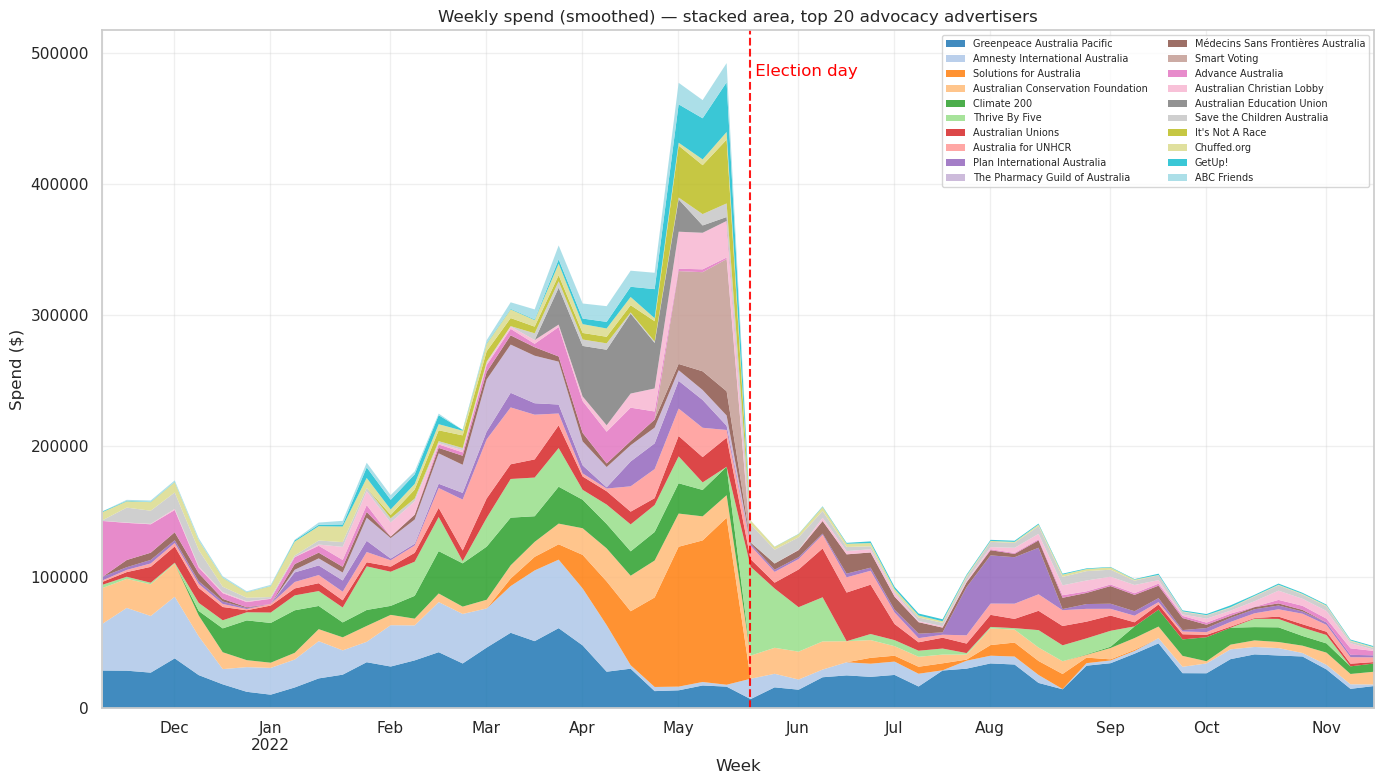

In [7]:
pivot_smooth = (weekly.pivot_table(index='week', columns='bylines',
                                    values='spend_smooth', aggfunc='sum')
                       .fillna(0)
                       [pivot.columns])  # same byline order as the raw pivot

fig, ax = plt.subplots(figsize=(14, 8))
pivot_smooth.plot.area(ax=ax, alpha=0.85, linewidth=0, colormap='tab20')
ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.9, linewidth=1.5)
ax.text(ELECTION_DATE + pd.Timedelta(days=2), ax.get_ylim()[1] * 0.95,
        ' Election day', color='red', va='top')
ax.set_title('Weekly spend (smoothed) — stacked area, top 20 advocacy advertisers')
ax.set_ylabel('Spend ($)')
ax.set_xlabel('Week')
ax.legend(loc='upper right', fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

small multiples, one panel per byline, grouped by band. shared x, independent y.

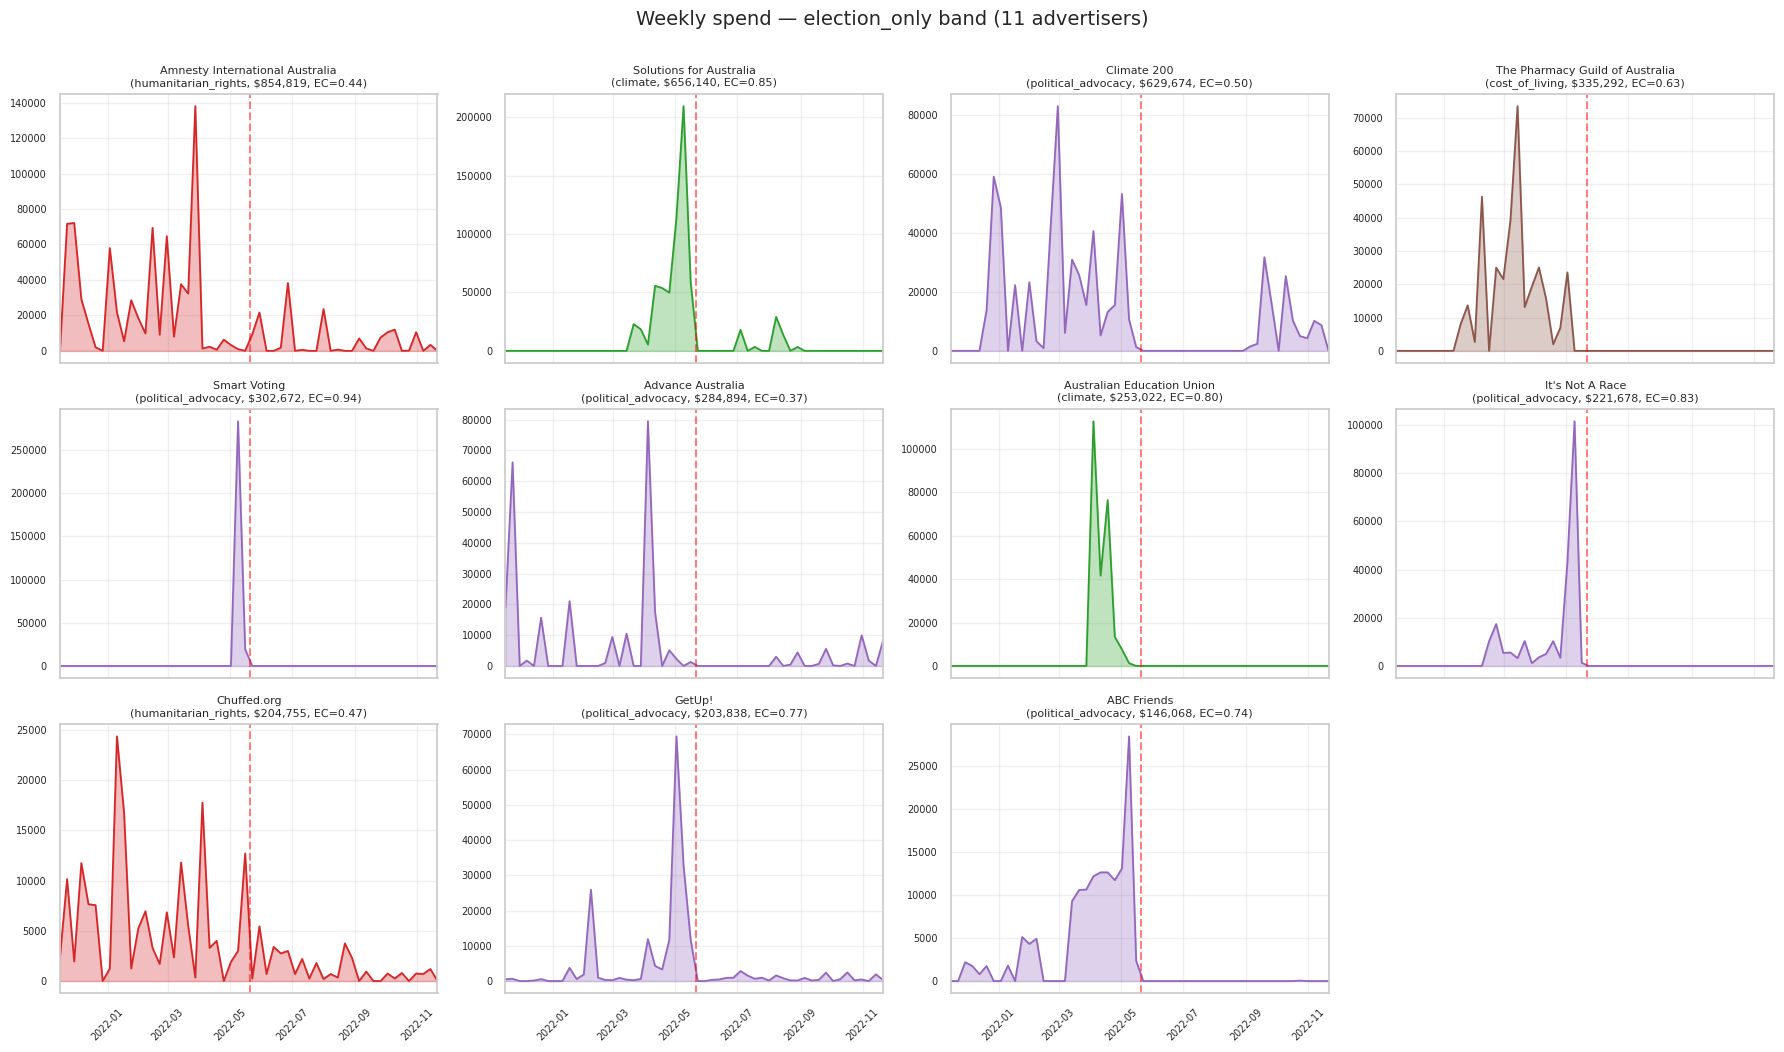

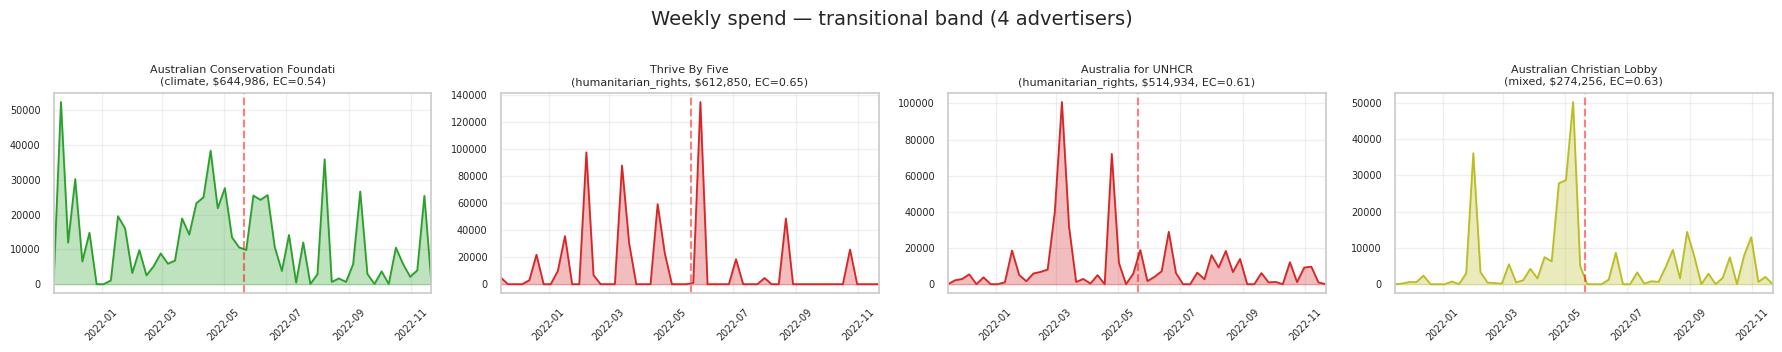

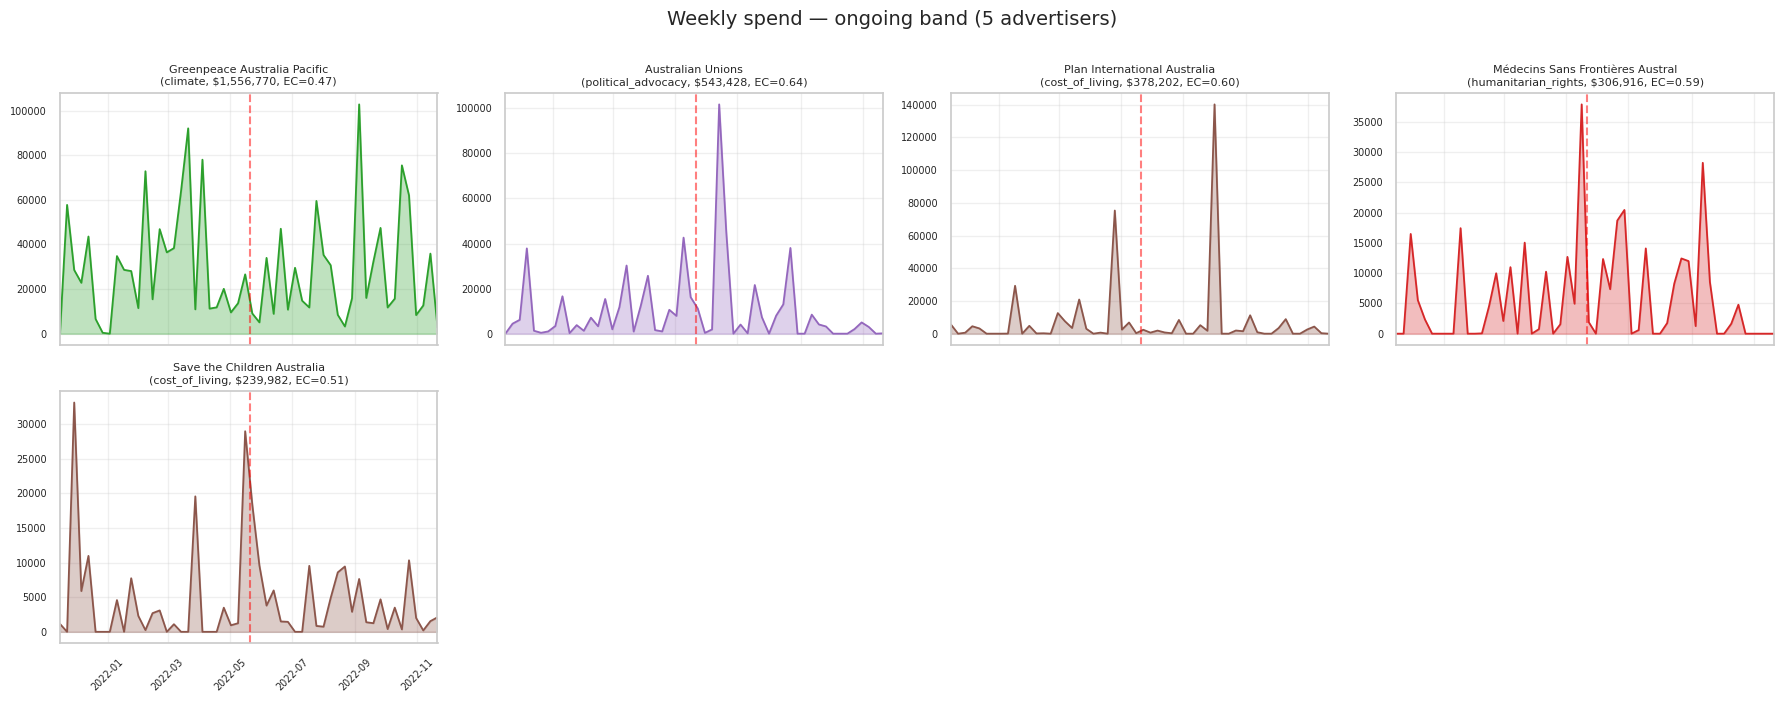

No advertisers in band "off_campaign".



In [8]:
import math

# Full time window for sharex.
x_min = weekly['week'].min()
x_max = weekly['week'].max()

for band_name in ['election_only', 'transitional', 'ongoing', 'off_campaign']:
    band_data = top20[top20['band'] == band_name].sort_values('total_spend', ascending=False).reset_index(drop=True)
    n = len(band_data)
    if n == 0:
        print(f'No advertisers in band "{band_name}".\n')
        continue

    ncols = min(4, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows),
                             squeeze=False, sharex=True, sharey=False)
    axes = axes.flatten()

    for i, row in band_data.iterrows():
        ax = axes[i]
        byline = row['bylines']
        grp = row['group']
        color = GROUP_COLORS.get(grp, '#777777')
        sub = weekly[weekly['bylines'] == byline].sort_values('week')
        ax.plot(sub['week'], sub['spend'], color=color, linewidth=1.3)
        ax.fill_between(sub['week'], sub['spend'], color=color, alpha=0.3)
        ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.5)
        ax.set_title(f'{byline[:32]}\n({grp}, ${row["total_spend"]:,.0f}, EC={row["ec_index"]:.2f})', fontsize=8)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(alpha=0.3)
        ax.set_xlim(x_min, x_max)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Weekly spend — {band_name} band ({n} advertisers)', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

quadrant scatter. x is spend imbalance (post − pre over total), y is centroid timing. bubble area is total spend, colour is band.

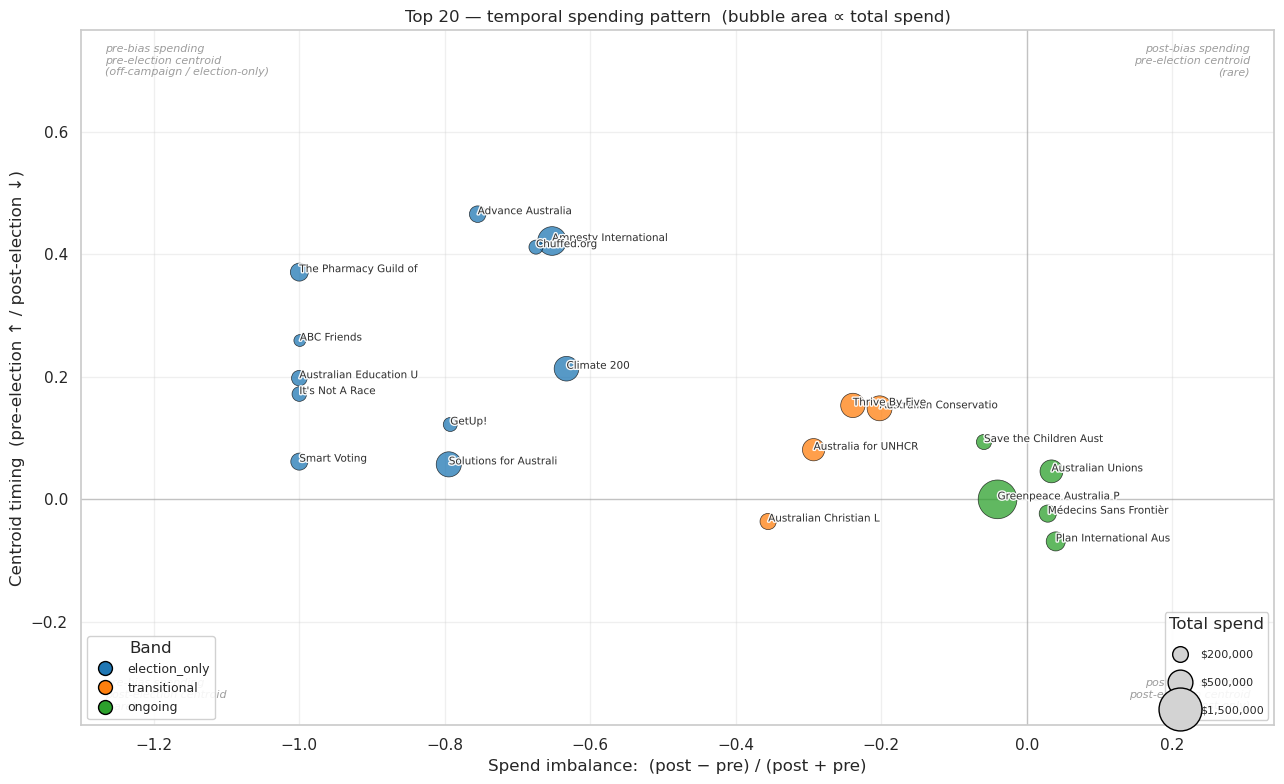

In [9]:
# temporal-pattern quadrant — spend imbalance (x) × centroid timing (y).

BAND_COLORS = {
    'election_only':   '#1f77b4',   # blue
    'transitional':    '#ff7f0e',   # orange
    'ongoing':         '#2ca02c',   # green
}

# axes — signed, normalised to ±1.
total = (top20['pre_spend'] + top20['post_spend']).replace(0, 1)
top20['x_imbalance'] = (top20['post_spend'] - top20['pre_spend']) / total
top20['y_centroid']  = (-top20['centroid_weeks'] / 26).clip(-1, 1)   # +ve = pre, −ve = post


def plot_quadrant(data, size_col, size_divisor, ref_sizes, size_legend_title,
                  size_label_fmt, chart_title):
    fig, ax = plt.subplots(figsize=(13, 8))

    ax.axhline(0, color='gray', linestyle='-', alpha=0.4, linewidth=1)
    ax.axvline(0, color='gray', linestyle='-', alpha=0.4, linewidth=1)

    sizes = data[size_col] / size_divisor
    colors = data['band'].astype(str).map(BAND_COLORS)
    ax.scatter(
        data['x_imbalance'], data['y_centroid'],
        s=sizes, c=colors, alpha=0.75,
        edgecolors='black', linewidths=0.5, zorder=3,
    )

    # labels — adjustText pushes them off the bubbles with leader lines.
    texts = [
        ax.text(row['x_imbalance'], row['y_centroid'], row['bylines'][:22],
                fontsize=7.5, alpha=0.95, zorder=5)
        for _, row in data.iterrows()
    ]

    try:
        from adjustText import adjust_text
        adjust_text(
            texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5, lw=0.6),
            expand_points=(2.0, 2.0),
            expand_text=(1.4, 1.6),
            force_points=(0.6, 0.8),
            force_text=(0.7, 0.9),
            lim=500,
            only_move={'points': 'xy', 'text': 'xy', 'objects': 'xy'},
        )
    except ImportError:
        from matplotlib import patheffects
        for t in texts:
            t.set_path_effects([patheffects.withStroke(linewidth=2.0, foreground='white')])

    # quadrant labels positioned in axes coordinates so they sit in the corners
    # regardless of the data range.
    ax.text(0.02, 0.98, 'pre-bias spending\npre-election centroid\n(off-campaign / election-only)',
            transform=ax.transAxes, ha='left',  va='top',
            fontsize=8, alpha=0.45, fontstyle='italic')
    ax.text(0.98, 0.98, 'post-bias spending\npre-election centroid\n(rare)',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, alpha=0.45, fontstyle='italic')
    ax.text(0.02, 0.02, 'pre-bias spending\npost-election centroid\n(rare)',
            transform=ax.transAxes, ha='left',  va='bottom',
            fontsize=8, alpha=0.45, fontstyle='italic')
    ax.text(0.98, 0.02, 'post-bias spending\npost-election centroid\n(post-only)',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=8, alpha=0.45, fontstyle='italic')

    from matplotlib.lines import Line2D
    band_handles = [
        Line2D([0], [0], marker='o', linestyle='', color='w',
               markerfacecolor=c, markeredgecolor='black', markersize=10, label=b)
        for b, c in BAND_COLORS.items()
    ]
    # Line2D markersize is diameter in points → 2 * sqrt(area / pi).
    size_handles = [
        Line2D([0], [0], marker='o', linestyle='', color='w',
               markerfacecolor='lightgray', markeredgecolor='black',
               markersize=2 * np.sqrt((s / size_divisor) / np.pi),
               label=size_label_fmt(s))
        for s in ref_sizes
    ]
    band_legend = ax.legend(handles=band_handles, loc='lower left', fontsize=9,
                            framealpha=0.9, title='Band')
    ax.add_artist(band_legend)
    ax.legend(handles=size_handles, loc='lower right', fontsize=8, framealpha=0.9,
              title=size_legend_title, labelspacing=1.6)

    # Auto-fit axes to data with 10% padding on each side. Ensure 0 stays in
    # range so the quadrant cross-hair (axhline / axvline) remains visible.
    x_min, x_max = data['x_imbalance'].min(), data['x_imbalance'].max()
    y_min, y_max = data['y_centroid'].min(), data['y_centroid'].max()
    x_pad = max((x_max - x_min) * 0.10, 0.3)
    y_pad = max((y_max - y_min) * 0.10, 0.3)
    ax.set_xlim(min(x_min - x_pad, -0.05), max(x_max + x_pad, 0.05))
    ax.set_ylim(min(y_min - y_pad, -0.05), max(y_max + y_pad, 0.05))

    ax.set_xlabel('Spend imbalance:  (post − pre) / (post + pre)')
    ax.set_ylabel('Centroid timing  (pre-election ↑ / post-election ↓)')
    ax.set_title(chart_title)
    ax.grid(alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()


plot_quadrant(
    top20,
    size_col='total_spend',
    size_divisor=2000,
    ref_sizes=[200_000, 500_000, 1_500_000],
    size_legend_title='Total spend',
    size_label_fmt=lambda s: f'${s:,.0f}',
    chart_title='Top 20 — temporal spending pattern  (bubble area ∝ total spend)',
)

same quadrant, bubble area is impressions instead of spend. comparison table at the end for spend rank vs impression rank.

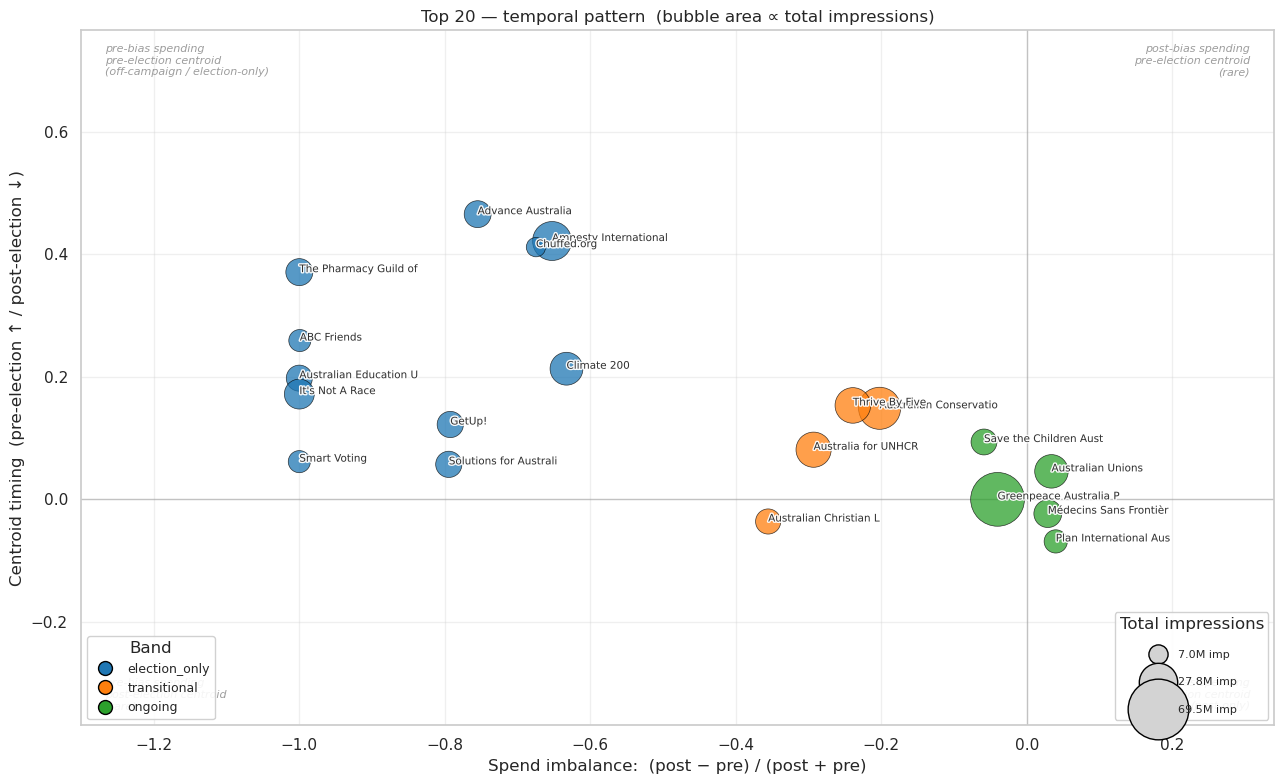

,bylines,spend_rank,imp_rank,rank_shift,cpm
2,Solutions for Australia,3,13,-10,39.626580
15,Plan International Australia,9,17,-8,29.110779
8,Smart Voting,12,18,-6,25.727588
3,Climate 200,5,7,-2,24.309106
13,Australian Christian Lobby,14,16,-2,18.043895
16,Chuffed.org,18,20,-2,22.744604
1,Amnesty International Australia,2,3,-1,23.373674
6,The Pharmacy Guild of Australia,10,10,0,19.130007
0,Greenpeace Australia Pacific,1,1,0,22.397573
10,Australian Education Union,15,14,1,15.478342


In [10]:
# aggregate total impressions per top-20 byline from v3.
imp_pdf = (v3
    .filter(col('bylines').isin(top20_bylines) & col('impressions_mid').isNotNull())
    .groupBy('bylines')
    .agg(spark_sum('impressions_mid').alias('total_impressions'))
    .toPandas())

top20_imp = top20.merge(imp_pdf, on='bylines', how='left')
top20_imp['total_impressions'] = top20_imp['total_impressions'].fillna(0)

# scale so the biggest bubble is similar to the spend chart.
imp_divisor = top20_imp['total_impressions'].max() / 1500
imp_max = top20_imp['total_impressions'].max()

plot_quadrant(
    top20_imp,
    size_col='total_impressions',
    size_divisor=imp_divisor,
    ref_sizes=[imp_max * 0.1, imp_max * 0.4, imp_max],
    size_legend_title='Total impressions',
    size_label_fmt=lambda s: f'{s/1e6:,.1f}M imp',
    chart_title='Top 20 — temporal pattern  (bubble area ∝ total impressions)',
)

# spend rank vs impression rank.
cmp = top20_imp[['bylines', 'total_spend', 'total_impressions']].copy()
cmp['spend_rank'] = cmp['total_spend'].rank(ascending=False).astype(int)
cmp['imp_rank']   = cmp['total_impressions'].rank(ascending=False).astype(int)
cmp['cpm']        = cmp['total_spend'] / (cmp['total_impressions'] / 1000).replace(0, pd.NA)
cmp['rank_shift'] = cmp['spend_rank'] - cmp['imp_rank']
cmp.sort_values('rank_shift')[['bylines', 'spend_rank', 'imp_rank', 'rank_shift', 'cpm']]

roll up to bands. count, total spend, mean persistence and EC per band.

In [11]:
band_summary = top20.groupby('band', observed=True).agg(
    n_advertisers=('bylines', 'count'),
    pre_spend=('pre_spend', 'sum'),
    post_spend=('post_spend', 'sum'),
    total_spend=('total_spend', 'sum'),
    mean_persistence=('persistence', 'mean'),
    mean_ec=('ec_index', 'mean'),
).reset_index()

band_summary['total_share'] = band_summary['total_spend'] / band_summary['total_spend'].sum()

band_summary

,band,n_advertisers,pre_spend,post_spend,total_spend,mean_persistence,mean_ec,total_share
0,election_only,11,3671926.0,420925.5,4092851.5,0.090705,0.667871,0.446566
1,transitional,4,1286303.0,760723.5,2047026.5,0.607737,0.606735,0.223348
2,ongoing,5,1529922.0,1495374.0,3025296.0,1.043606,0.558868,0.330086


the advocacy ecosystem splits into four patterns, with election_only the biggest by count and greenpeace dominating the ongoing band. shell only shows up as off_campaign once you combine persistence with centroid.

In [12]:
BAND_EXPORT_PATH = '../data/top20_bands.csv'

export_df = (top20[['bylines', 'band', 'group', 'pre_spend', 'post_spend',
                     'total_spend', 'persistence', 'centroid_weeks', 'ec_index']]
             .sort_values(['band', 'total_spend'], ascending=[True, False])
             .reset_index(drop=True))
export_df['band'] = export_df['band'].astype(str)

export_df.to_csv(BAND_EXPORT_PATH, index=False)
print(f'Wrote {BAND_EXPORT_PATH}')
display(export_df)

Wrote ../data/top20_bands.csv


,bylines,band,group,pre_spend,post_spend,total_spend,persistence,centroid_weeks,ec_index
0,Amnesty International Australia,election_only,humanitarian_rights,706331.5,148487.5,854819.0,0.211750,-10.954066,0.441121
1,Solutions for Australia,election_only,climate,588735.5,67405.0,656140.5,0.125119,-1.477411,0.852070
2,Climate 200,election_only,political_advocacy,514056.5,115618.0,629674.5,0.222743,-5.535371,0.499911
3,The Pharmacy Guild of Australia,election_only,cost_of_living,335291.5,0.0,335291.5,0.000000,-9.633387,0.629485
4,Smart Voting,election_only,political_advocacy,302671.5,0.0,302671.5,0.000000,-1.592891,0.938735
5,Advance Australia,election_only,political_advocacy,249974.5,34919.0,284893.5,0.115904,-12.092769,0.374626
6,Australian Education Union,election_only,climate,253022.5,0.0,253022.5,0.000000,-5.134448,0.802521
7,It's Not A Race,election_only,political_advocacy,221677.5,0.0,221677.5,0.000000,-4.459645,0.828475
8,Chuffed.org,election_only,humanitarian_rights,171455.5,33299.5,204755.0,0.205657,-10.693799,0.471631
9,GetUp!,election_only,political_advocacy,182691.0,21147.0,203838.0,0.116235,-3.168807,0.767506


export top 20 bylines + band as csv for nb 06 to consume.

for each of the three main bands (election_only, transitional, ongoing), show every advertiser and their top 5 keywords from ad body + title text. regex tokenise, lowercase, drop stopwords.

In [13]:
from pyspark.sql.functions import (
    row_number, explode, lower, regexp_replace, split, length,
    concat_ws, array_join, collect_list,
)
from pyspark.sql.window import Window
from pyspark.ml.feature import StopWordsRemover

# english stopwords plus a few domain words that don't differentiate australian
# political advocacy bylines (everyone says 'australia', 'sign', etc).
STOP = set(StopWordsRemover.loadDefaultStopWords('english')) | {
    'australia', 'australian', 'australians', 'sign', 'petition', 'please',
    'today', 'help', 'support', 'make', 'get', 'one', 'us', 'go',
    'http', 'https', 'www', 'com', 'au',
}

top_keywords_by_band = {}
for band_name in ['election_only', 'transitional', 'ongoing']:
    band_bylines = top20.loc[top20['band'] == band_name, 'bylines'].tolist()
    if not band_bylines:
        top_keywords_by_band[band_name] = pd.DataFrame()
        continue

    # combine body + title arrays into one text blob per ad, tokenise.
    tokens = (v3
        .filter(col('bylines').isin(band_bylines))
        .withColumn('text', concat_ws(' ',
            array_join('creative_bodies', ' '),
            array_join('creative_link_titles', ' ')))
        .withColumn('text', regexp_replace(lower('text'), r'[^a-z\s]', ' '))
        .withColumn('token', explode(split(col('text'), r'\s+')))
        .filter(length('token') > 2)
        .filter(~col('token').isin(list(STOP))))

    counts = tokens.groupBy('bylines', 'token').count()
    w = Window.partitionBy('bylines').orderBy(desc('count'), 'token')
    top5 = (counts
        .withColumn('rn', row_number().over(w))
        .filter(col('rn') <= 5)
        .orderBy('bylines', 'rn')
        .groupBy('bylines')
        .agg(collect_list('token').alias('top_keywords'))
        .toPandas())

    # preserve band ordering by total spend.
    order = (top20.loc[top20['band'] == band_name]
                  .sort_values('total_spend', ascending=False)['bylines']
                  .tolist())
    top5['_order'] = top5['bylines'].map({b: i for i, b in enumerate(order)})
    top5 = top5.sort_values('_order').drop(columns='_order').reset_index(drop=True)
    top5['top_keywords'] = top5['top_keywords'].apply(lambda xs: ', '.join(xs))
    top_keywords_by_band[band_name] = top5

for band_name, df in top_keywords_by_band.items():
    print(f'\n=== {band_name} ({len(df)} advertisers) ===')
    display(df)


=== election_only (11 advertisers) ===


,bylines,top_keywords
0,Amnesty International Australia,"people, quiz, take, rights, free"
1,Solutions for Australia,"energy, power, government, federal, jobs"
2,Climate 200,"climate, vote, independent, party, independents"
3,The Pharmacy Guild of Australia,"medicines, cost, prescription, visit, choose"
4,Smart Voting,"last, put, liberals, source, afford"
5,Advance Australia,"vaccine, freedom, fair, show, choice"
6,Australian Education Union,"morrison, government, vote, schools, tafe"
7,It's Not A Race,"auspol, climate, climateaction, change, right"
8,Chuffed.org,"people, aboriginal, chip, first, nations"
9,GetUp!,"vote, election, government, climate, morrison"



=== transitional (4 advertisers) ===


,bylines,top_keywords
0,Australian Conservation Foundation,"protect, climb, climate, laws, nature"
1,Thrive By Five,"early, learning, educators, childcare, families"
2,Australia for UNHCR,"refugees, ukraine, donate, unhcr, winter"
3,Australian Christian Lobby,"truth, party, religious, schools, faith"



=== ongoing (5 advertisers) ===


,bylines,top_keywords
0,Greenpeace Australia Pacific,"woodside, gas, climate, tell, oceans"
1,Australian Unions,"union, free, morrison, join, joining"
2,Plan International Australia,"girls, add, fgm, name, every"
3,Médecins Sans Frontières Australia,"medical, people, care, teams, need"
4,Save the Children Australia,"children, child, end, protect, take"


mine an "election vocabulary" from the election_only band, then track how heavily every top-20 advertiser uses that vocabulary week by week. catches content-pivoting that the spend-timing bands miss: an ongoing advocacy org that swaps single-issue messaging for election messaging in the run-up, then swaps back, has steady spend but a keyword-density spike.

In [14]:
# Election vocabulary — the dominant tokens used by the election_only band.
# Same tokenise/stopword recipe as the per-band keyword cell above (STOP reused from there).
N_ELECTION_KEYWORDS = 30

election_only_bylines = top20.loc[top20['band'] == 'election_only', 'bylines'].tolist()
print(f'election_only band: {len(election_only_bylines)} advertisers')

election_tokens = (v3
    .filter(col('bylines').isin(election_only_bylines))
    .withColumn('text', concat_ws(' ',
        array_join('creative_bodies', ' '),
        array_join('creative_link_titles', ' ')))
    .withColumn('text', regexp_replace(lower('text'), r'[^a-z\s]', ' '))
    .withColumn('token', explode(split(col('text'), r'\s+')))
    .filter(length('token') > 2)
    .filter(~col('token').isin(list(STOP))))

election_vocab_pdf = (election_tokens.groupBy('token').count()
    .orderBy(desc('count'), 'token')
    .limit(N_ELECTION_KEYWORDS)
    .toPandas())

ELECTION_VOCAB = election_vocab_pdf['token'].tolist()
print(f'\nElection vocabulary (top {N_ELECTION_KEYWORDS} tokens from election_only band):')
print(', '.join(ELECTION_VOCAB))
election_vocab_pdf

election_only band: 11 advertisers

Election vocabulary (top 30 tokens from election_only band):
government, abc, people, climate, medicines, power, vote, federal, cost, take, like, energy, right, jobs, need, save, life, independent, time, free, prescription, women, change, quiz, protect, morrison, action, freedom, know, rights


,token,count
0,government,2985
1,abc,2899
2,people,2822
3,climate,2257
4,medicines,1959
5,power,1889
6,vote,1686
7,federal,1602
8,cost,1566
9,take,1546


apply that vocabulary to all top-20 advertisers. per advertiser per week, density = total election-keyword hits (token occurrences, with repeats) / number of ads — so a high value means each ad is leaning hard on election language, independent of how many ads ran. stacked area shows the weekly mix; the per-byline rollup (kw_density_overall, kw_density_pre, kw_density_post) is merged onto top20 as a third metric alongside spend and impressions.

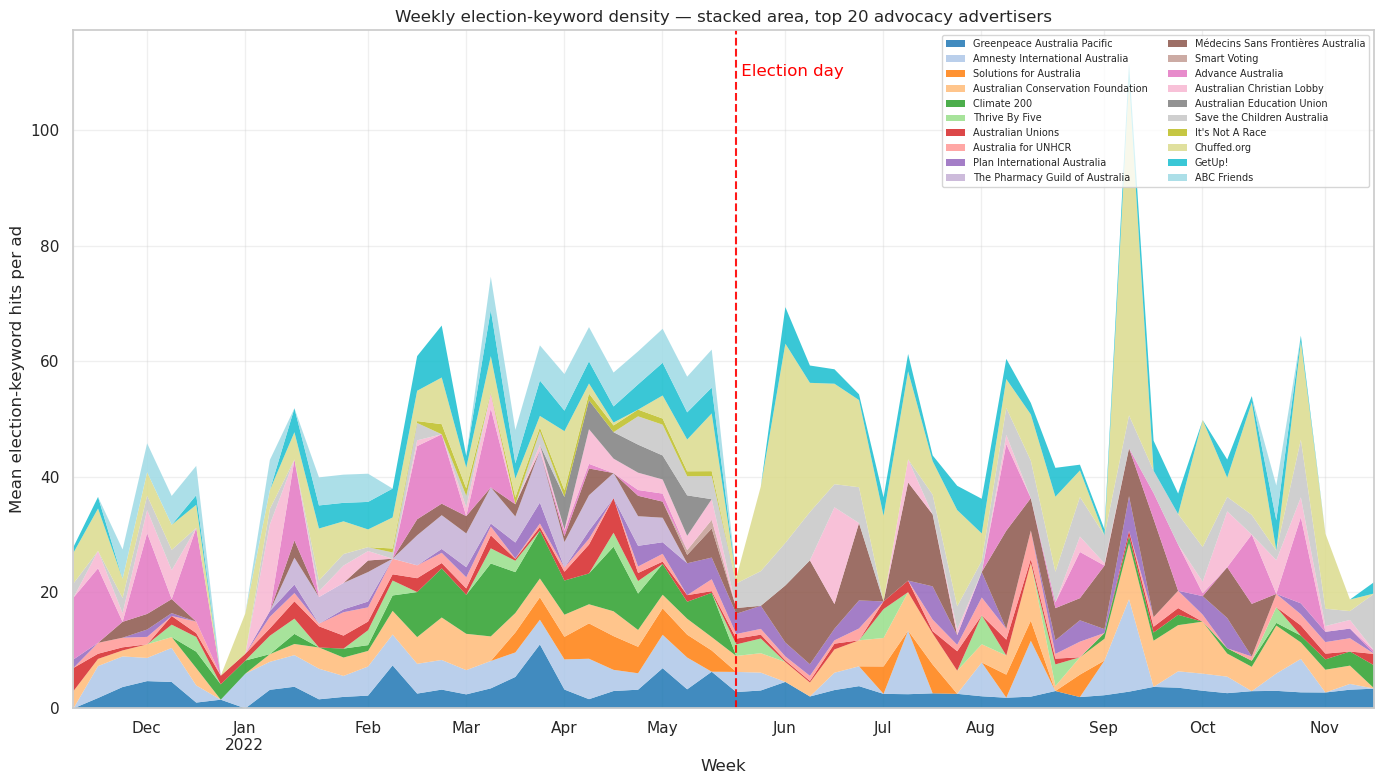

,bylines,group,band,kw_density_pre,kw_density_post,kw_density_overall
11,Advance Australia,political_advocacy,election_only,8.609800,9.741935,8.724307
16,Chuffed.org,humanitarian_rights,election_only,5.531579,14.040000,8.465517
17,Médecins Sans Frontières Australia,humanitarian_rights,ongoing,2.995633,8.362500,5.742004
18,ABC Friends,political_advocacy,election_only,5.595597,6.000000,5.596065
6,The Pharmacy Guild of Australia,cost_of_living,election_only,5.366765,0.000000,5.366765
10,Australian Education Union,climate,election_only,4.784314,0.000000,4.784314
2,Solutions for Australia,climate,election_only,4.762290,4.200000,4.734469
1,Amnesty International Australia,humanitarian_rights,election_only,4.771723,3.960000,4.690981
19,Save the Children Australia,cost_of_living,ongoing,3.016563,5.084991,4.120656
14,GetUp!,political_advocacy,election_only,4.418239,3.084906,4.084906


In [15]:
from pyspark.sql.functions import count as spark_count

filt = col('bylines').isin(top20_bylines)

# n_ads per (byline, week) — keeps zero-hit ads in the denominator.
ads_per_week = (v3.filter(filt)
    .withColumn('week', date_trunc('week', 'ad_creation_date'))
    .groupBy('bylines', 'week')
    .agg(spark_count('*').alias('n_ads')))

# election-keyword hits per (byline, week) — explode tokens, keep vocab matches, count with repeats.
hits_per_week = (v3.filter(filt)
    .withColumn('week', date_trunc('week', 'ad_creation_date'))
    .withColumn('text', regexp_replace(lower(concat_ws(' ',
        array_join('creative_bodies', ' '),
        array_join('creative_link_titles', ' '))), r'[^a-z\s]', ' '))
    .withColumn('token', explode(split(col('text'), r'\s+')))
    .filter(col('token').isin(ELECTION_VOCAB))
    .groupBy('bylines', 'week')
    .agg(spark_count('*').alias('n_hits')))

kw_density = (ads_per_week
    .join(hits_per_week, ['bylines', 'week'], 'left')
    .na.fill(0, ['n_hits'])
    .withColumn('kw_density', col('n_hits') / col('n_ads'))
    .toPandas())

# Pivot to byline x week, reindex onto the full weekly grid (zero-fill missing weeks),
# reuse the byline column order from the spend pivot so colours stay consistent.
kw_pivot = kw_density.pivot_table(index='week', columns='bylines',
                                  values='kw_density', aggfunc='sum').fillna(0)
all_weeks = pd.date_range(kw_pivot.index.min(), kw_pivot.index.max(), freq='W-MON')
kw_pivot = kw_pivot.reindex(all_weeks, fill_value=0)
kw_pivot = kw_pivot[[b for b in pivot.columns if b in kw_pivot.columns]]

fig, ax = plt.subplots(figsize=(14, 8))
kw_pivot.plot.area(ax=ax, alpha=0.85, linewidth=0, colormap='tab20')
ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.9, linewidth=1.5)
ax.text(ELECTION_DATE + pd.Timedelta(days=2), ax.get_ylim()[1] * 0.95,
        ' Election day', color='red', va='top')
ax.set_title('Weekly election-keyword density — stacked area, top 20 advocacy advertisers')
ax.set_ylabel('Mean election-keyword hits per ad')
ax.set_xlabel('Week')
ax.legend(loc='upper right', fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Per-byline rollup — overall / pre / post mean election-keyword hits per ad.
kw_density['is_post'] = kw_density['week'] >= ELECTION_DATE
def _kw_rollup(g):
    return pd.Series({
        'kw_density_overall': g['n_hits'].sum() / max(g['n_ads'].sum(), 1),
        'kw_density_pre':  g.loc[~g['is_post'], 'n_hits'].sum() / max(g.loc[~g['is_post'], 'n_ads'].sum(), 1),
        'kw_density_post': g.loc[g['is_post'], 'n_hits'].sum() / max(g.loc[g['is_post'], 'n_ads'].sum(), 1),
    })
kw_rollup = kw_density.groupby('bylines').apply(_kw_rollup).reset_index()

for c in ('kw_density_overall', 'kw_density_pre', 'kw_density_post'):
    if c in top20.columns:
        top20 = top20.drop(columns=[c])
top20 = top20.merge(kw_rollup, on='bylines', how='left')

top20.sort_values('kw_density_overall', ascending=False)[
    ['bylines', 'group', 'band', 'kw_density_pre', 'kw_density_post', 'kw_density_overall']]

In [16]:
MIN_ADS = 20
MIN_SPEND = 1000.0

# bylines with enough data to band reliably.
advertiser_stats = (v3
    .filter(col('bylines').isNotNull() & col('spend_mid').isNotNull())
    .groupBy('bylines')
    .agg(spark_count('*').alias('n_ads'),
         spark_sum('spend_mid').alias('total_spend'))
    .filter((col('n_ads') >= MIN_ADS) & (col('total_spend') >= MIN_SPEND))
    .toPandas())

all_bylines = advertiser_stats['bylines'].tolist()
print(f'Bylines with >= {MIN_ADS} ads and >= ${MIN_SPEND:.0f} spend: {len(all_bylines):,}')

# weekly spend per byline for the qualifying set.
weekly_all = (v3
    .filter(col('bylines').isin(all_bylines) & col('spend_mid').isNotNull())
    .withColumn('week', date_trunc('week', 'ad_creation_date'))
    .groupBy('week', 'bylines')
    .agg(spark_sum('spend_mid').alias('spend'))
    .toPandas())

# collapse any duplicate (bylines, week) — defensive even though groupby above
# should already make them unique.
weekly_all = weekly_all.groupby(['bylines', 'week'], as_index=False)['spend'].sum()

# reindex to a complete weekly grid so the rolling window sees zero weeks.
all_weeks = pd.date_range(weekly_all['week'].min(), weekly_all['week'].max(), freq='W-MON')
full_index = pd.MultiIndex.from_product([all_bylines, all_weeks],
                                         names=['bylines', 'week'])
weekly_all = (weekly_all.set_index(['bylines', 'week'])
              .reindex(full_index, fill_value=0.0)
              .reset_index()
              .sort_values(['bylines', 'week']))

# split-half smoothing — pre and post halves smoothed independently so the
# election-day boundary is respected.
weekly_all['is_post'] = weekly_all['week'] >= ELECTION_DATE
weekly_all['spend_smooth'] = (weekly_all.groupby(['bylines', 'is_post'])['spend']
    .transform(lambda s: s.rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).mean()))

# triangle weights for the EC index.
weekly_all['weeks_from_election'] = (weekly_all['week'] - ELECTION_DATE).dt.days / 7
weekly_all['weight'] = np.clip(
    1.0 - np.abs(weekly_all['weeks_from_election']) / HALF_WIDTH_WEEKS,
    a_min=0.0, a_max=None,
)
weekly_all['weighted_spend_smooth'] = weekly_all['weight'] * weekly_all['spend_smooth']

# per-byline summary metrics from smoothed series.
def _summary_all(x):
    total = x['spend_smooth'].sum()
    if total <= 0:
        return pd.Series({'pre_spend_s': 0.0, 'post_spend_s': 0.0,
                          'ec_index': 0.0, 'centroid_weeks': 0.0})
    pre  = x.loc[~x['is_post'], 'spend_smooth'].sum()
    post = x.loc[ x['is_post'], 'spend_smooth'].sum()
    return pd.Series({
        'pre_spend_s':    pre,
        'post_spend_s':   post,
        'ec_index':       x['weighted_spend_smooth'].sum() / total,
        'centroid_weeks': (x['weeks_from_election'] * x['spend_smooth']).sum() / total,
    })

smoothed_all = weekly_all.groupby('bylines').apply(_summary_all).reset_index()
smoothed_all['persistence'] = smoothed_all['post_spend_s'] / smoothed_all['pre_spend_s'].replace(0, pd.NA)

all_bylines_df = smoothed_all.merge(advertiser_stats, on='bylines', how='left')
all_bylines_df['band'] = all_bylines_df.apply(_classify, axis=1)

# write.
ALL_BANDS_CSV = '../data/all_bylines_bands.csv'
all_bylines_df_out = all_bylines_df[['bylines', 'band', 'n_ads', 'total_spend',
                                      'pre_spend_s', 'post_spend_s',
                                      'persistence', 'centroid_weeks', 'ec_index']]
all_bylines_df_out.to_csv(ALL_BANDS_CSV, index=False)

print(f'\nWrote {ALL_BANDS_CSV}')
print('\nBand distribution across all qualifying bylines:')
print(all_bylines_df['band'].value_counts())
print('\nAd-row totals per band (training-set size for nb 06):')
band_ads = (all_bylines_df[['bylines', 'band']]
            .merge(advertiser_stats, on='bylines')
            .groupby('band')['n_ads'].sum())
print(band_ads)

Bylines with >= 20 ads and >= $1000 spend: 567

Wrote ../data/all_bylines_bands.csv

Band distribution across all qualifying bylines:
band
ongoing          222
election_only    166
off_campaign     101
transitional      78
Name: count, dtype: int64

Ad-row totals per band (training-set size for nb 06):
band
election_only    22029
off_campaign      6578
ongoing          41608
transitional     13442
Name: n_ads, dtype: int64


extend the banding to every advocacy advertiser with enough activity (>= 20 ads and >= $1k total spend). reuses the same smoothing + persistence + centroid pipeline as the top-20 banding but applied across the whole corpus. exported csv feeds nb 06.